# Dự báo lưu lượng giao thông 24 giờ tiếp theo

Notebook này trình bày quy trình xây dựng mô hình dự báo lưu lượng giao thông cho **24 giờ tiếp theo** dựa trên dữ liệu đã được tiền xử lý trước đó.  
Mục tiêu là sử dụng các đặc trưng về thời gian và thời tiết để huấn luyện mô hình Random Forest, sau đó tạo dữ liệu tương lai và dự đoán số lượng phương tiện theo từng giờ.

## Nội dung chính

- Đọc và chuẩn hóa dữ liệu đầu vào
- Tạo tập đặc trưng phục vụ huấn luyện
- Chia dữ liệu train/test
- Huấn luyện mô hình Random Forest
- Đánh giá nhanh độ chính xác của mô hình
- Tạo dữ liệu cho 24 giờ tiếp theo và sinh dự báo
- Lưu kết quả và trực quan hóa bằng biểu đồ

## Ý nghĩa

Kết quả của notebook có thể hỗ trợ việc phân tích xu hướng giao thông ngắn hạn, phục vụ điều phối, giám sát hoặc làm cơ sở cho các bước phân tích nâng cao hơn.


## 1. Import th? vi?n


Phần này nạp các thư viện cần thiết cho toàn bộ quá trình xử lý dữ liệu, huấn luyện mô hình và trực quan hóa kết quả. Các thư viện chính gồm pandas, numpy, matplotlib và các thành phần trong scikit-learn.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


## 2. Load d? li?u


Ở bước này, chương trình đọc dữ liệu từ file CSV và chuyển cột thời gian về đúng định dạng datetime. Đây là bước quan trọng để có thể trích xuất các đặc trưng theo giờ, ngày hoặc khoảng thời gian trong các bước tiếp theo.


In [14]:
df = pd.read_csv("traffic_cleaned.csv")

# ??m b?o datetime ??ng ki?u
df["datetime"] = pd.to_datetime(df["datetime"])

print("K?ch th??c d? li?u:", df.shape)
display(df.head())


K?ch th??c d? li?u: (48204, 15)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,datetime,hour,day,month,dayofweek,is_weekend
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,2012-10-02 09:00:00,9,2,10,1,0
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,2012-10-02 10:00:00,10,2,10,1,0
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,2012-10-02 11:00:00,11,2,10,1,0
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,2012-10-02 12:00:00,12,2,10,1,0
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,2012-10-02 13:00:00,13,2,10,1,0


## 3. Chu?n b? d? li?u hu?n luy?n


Bước chuẩn bị dữ liệu nhằm biến đổi dữ liệu gốc thành dạng phù hợp cho mô hình học máy. Trong đó, biến phân loại như thời tiết sẽ được mã hóa one-hot, còn các cột đặc trưng đầu vào sẽ được chọn lọc để dùng cho việc dự đoán lưu lượng giao thông.


In [15]:
# One-hot encode weather_main
df_model = pd.get_dummies(df, columns=["weather_main"], drop_first=True)

# Ch?n feature
base_features = [
    "hour", "day", "month", "dayofweek", "is_weekend",
    "temp", "rain_1h", "snow_1h", "clouds_all"
]

weather_features = [col for col in df_model.columns if col.startswith("weather_main_")]
features = base_features + weather_features

X = df_model[features]
y = df_model["traffic_volume"]

print("S? l??ng feature:", len(features))
print(features)


S? l??ng feature: 19
['hour', 'day', 'month', 'dayofweek', 'is_weekend', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main_Clouds', 'weather_main_Drizzle', 'weather_main_Fog', 'weather_main_Haze', 'weather_main_Mist', 'weather_main_Rain', 'weather_main_Smoke', 'weather_main_Snow', 'weather_main_Squall', 'weather_main_Thunderstorm']


## 4. Chia train/test


Dữ liệu được chia thành hai phần: tập huấn luyện và tập kiểm tra. Tập huấn luyện dùng để mô hình học quy luật từ dữ liệu, còn tập kiểm tra dùng để đánh giá khả năng dự đoán trên dữ liệu chưa thấy trước đó.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (38563, 19)
Test size: (9641, 19)


## 5. Hu?n luy?n model Random Forest


Tại đây, mô hình Random Forest Regressor được khởi tạo và huấn luyện. Đây là thuật toán mạnh trong các bài toán hồi quy phi tuyến, có khả năng học tốt từ nhiều đặc trưng khác nhau và thường cho kết quả ổn định trên dữ liệu thực tế.


In [17]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 6. ??nh gi? nhanh model


Sau khi huấn luyện, mô hình được đánh giá nhanh thông qua các chỉ số sai số như MAE và RMSE. Các chỉ số này giúp đo mức độ chênh lệch giữa giá trị thực tế và giá trị dự đoán, từ đó phản ánh chất lượng mô hình.


In [18]:
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== ??NH GI? MODEL RANDOM FOREST ===")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")


=== ??NH GI? MODEL RANDOM FOREST ===
MAE  : 215.03
RMSE : 382.27


## 7. T?o d? li?u t??ng lai cho 24 gi? ti?p theo


Bước này tạo ra khung thời gian cho 24 giờ tiếp theo kể từ mốc cuối cùng trong dữ liệu gốc. Đây là cơ sở để sinh ra bộ dữ liệu tương lai mà mô hình sẽ sử dụng để đưa ra dự báo.


In [19]:
# D? ?o?n 24 gi? ti?p theo k? t? m?c cu?i c?ng trong d? li?u
last_time = df["datetime"].max()
future_times = pd.date_range(
    start=last_time + pd.Timedelta(hours=1),
    periods=24,
    freq="h"
)

future_df = pd.DataFrame({
    "datetime": future_times
})

# T?o feature th?i gian
future_df["hour"] = future_df["datetime"].dt.hour
future_df["day"] = future_df["datetime"].dt.day
future_df["month"] = future_df["datetime"].dt.month
future_df["dayofweek"] = future_df["datetime"].dt.dayofweek
future_df["is_weekend"] = future_df["dayofweek"].apply(lambda x: 1 if x >= 5 else 0)

print("Kho?ng d? b?o:", future_df["datetime"].min(), "??n", future_df["datetime"].max())
display(future_df.head())


Kho?ng d? b?o: 2018-10-01 00:00:00 ??n 2018-10-01 23:00:00


,datetime,hour,day,month,dayofweek,is_weekend
0,2018-10-01 00:00:00,0,1,10,0,0
1,2018-10-01 01:00:00,1,1,10,0,0
2,2018-10-01 02:00:00,2,1,10,0,0
3,2018-10-01 03:00:00,3,1,10,0,0
4,2018-10-01 04:00:00,4,1,10,0,0


## 8. G?n gi? tr? th?i ti?t cho t??ng lai

Trong b?n demo n?y, c?c bi?n th?i ti?t s? d?ng gi? tr? trung b?nh t? d? li?u g?c v? `weather_main` ???c gi? ??nh l? `Clouds`.


Vì dữ liệu tương lai thường chưa có thông tin thời tiết thực tế, notebook sử dụng các giá trị trung bình hoặc giá trị giả định từ dữ liệu lịch sử để gán cho các biến thời tiết. Cách làm này phù hợp cho mục đích minh họa quy trình dự báo.


In [20]:
future_df["temp"] = df["temp"].mean()
future_df["rain_1h"] = df["rain_1h"].mean()
future_df["snow_1h"] = df["snow_1h"].mean()
future_df["clouds_all"] = df["clouds_all"].mean()

future_df["weather_main"] = "Clouds"

display(future_df.head())


,datetime,hour,day,month,dayofweek,is_weekend,temp,rain_1h,snow_1h,clouds_all,weather_main
0,2018-10-01 00:00:00,0,1,10,0,0,281.20587,0.334264,0.000222,49.362231,Clouds
1,2018-10-01 01:00:00,1,1,10,0,0,281.20587,0.334264,0.000222,49.362231,Clouds
2,2018-10-01 02:00:00,2,1,10,0,0,281.20587,0.334264,0.000222,49.362231,Clouds
3,2018-10-01 03:00:00,3,1,10,0,0,281.20587,0.334264,0.000222,49.362231,Clouds
4,2018-10-01 04:00:00,4,1,10,0,0,281.20587,0.334264,0.000222,49.362231,Clouds


## 9. One-hot encode cho d? li?u t??ng lai


Dữ liệu tương lai tiếp tục được biến đổi về đúng cấu trúc đầu vào giống với dữ liệu huấn luyện, đặc biệt là phần mã hóa one-hot. Việc đồng nhất số lượng và tên cột là điều kiện bắt buộc để mô hình có thể dự đoán chính xác.


In [21]:
future_model = pd.get_dummies(future_df, columns=["weather_main"], drop_first=True)

# ??m b?o future c? ?? c?t gi?ng train
for col in features:
    if col not in future_model.columns:
        future_model[col] = 0

# S?p ??ng th? t? c?t
future_model = future_model[features]

display(future_model.head())


,hour,day,month,dayofweek,is_weekend,temp,rain_1h,snow_1h,clouds_all,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,0,1,10,0,0,281.20587,0.334264,0.000222,49.362231,0,0,0,0,0,0,0,0,0,0
1,1,1,10,0,0,281.20587,0.334264,0.000222,49.362231,0,0,0,0,0,0,0,0,0,0
2,2,1,10,0,0,281.20587,0.334264,0.000222,49.362231,0,0,0,0,0,0,0,0,0,0
3,3,1,10,0,0,281.20587,0.334264,0.000222,49.362231,0,0,0,0,0,0,0,0,0,0
4,4,1,10,0,0,281.20587,0.334264,0.000222,49.362231,0,0,0,0,0,0,0,0,0,0


## 10. D? ?o?n 24 gi? ti?p theo


Sau khi hoàn tất dữ liệu đầu vào cho tương lai, mô hình sẽ dự đoán lưu lượng giao thông tương ứng cho từng mốc thời gian trong 24 giờ tiếp theo. Kết quả được lưu vào DataFrame để tiện quan sát và xuất file.


In [22]:
future_df["predicted_traffic_volume"] = rf.predict(future_model)

print("=== D? ?O?N 24 GI? TI?P THEO ===")
display(future_df[["datetime", "predicted_traffic_volume"]])


=== D? ?O?N 24 GI? TI?P THEO ===


,datetime,predicted_traffic_volume
0,2018-10-01 00:00:00,517.36
1,2018-10-01 01:00:00,368.32
2,2018-10-01 02:00:00,232.39
3,2018-10-01 03:00:00,336.37
4,2018-10-01 04:00:00,764.16
5,2018-10-01 05:00:00,2065.14
6,2018-10-01 06:00:00,4878.86
7,2018-10-01 07:00:00,6076.77
8,2018-10-01 08:00:00,5357.51
9,2018-10-01 09:00:00,4575.87


## 11. L?u file k?t qu?


Kết quả dự báo được lưu ra file CSV để phục vụ cho việc sử dụng lại, tổng hợp báo cáo hoặc làm đầu vào cho các hệ thống khác. Đây là bước giúp đầu ra của notebook có thể tái sử dụng ngoài môi trường phân tích.


In [23]:
future_df.to_csv("future_traffic_prediction.csv", index=False)
print("?? l?u file: future_traffic_prediction.csv")


?? l?u file: future_traffic_prediction.csv


## 12. V? bi?u ?? d? ?o?n


Biểu đồ đường được sử dụng để trực quan hóa xu hướng lưu lượng giao thông dự báo theo thời gian. Nhờ đó, người xem có thể dễ dàng nhận ra các khung giờ tăng cao, giảm thấp và hình dung rõ biến động trong 24 giờ tiếp theo.


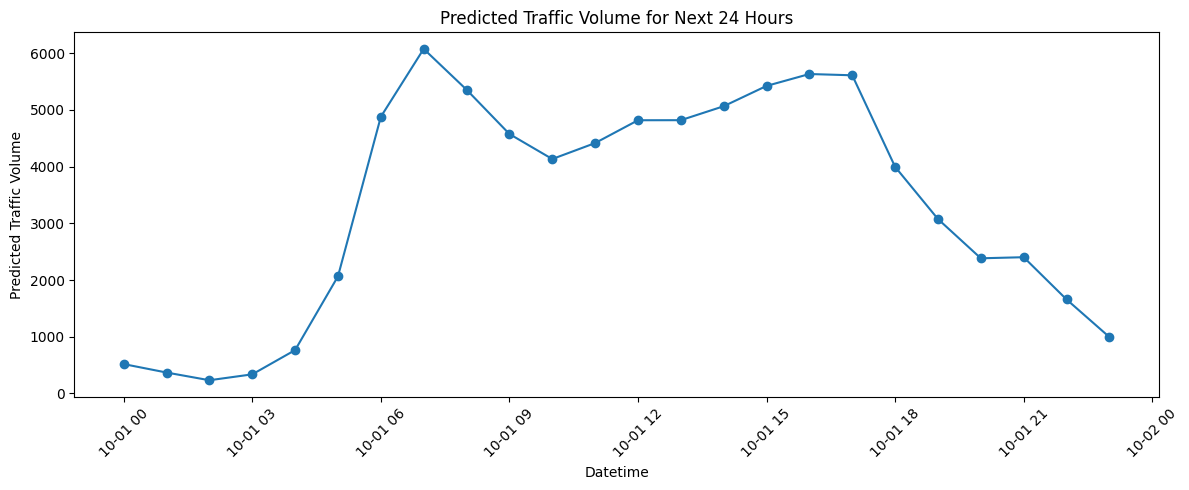

In [24]:
plt.figure(figsize=(12, 5))
plt.plot(future_df["datetime"], future_df["predicted_traffic_volume"], marker="o")
plt.title("Predicted Traffic Volume for Next 24 Hours")
plt.xlabel("Datetime")
plt.ylabel("Predicted Traffic Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Kết luận

Notebook đã hoàn thành quy trình dự báo lưu lượng giao thông cho **24 giờ tiếp theo** bằng mô hình Random Forest.  
Từ dữ liệu lịch sử, hệ thống tiến hành huấn luyện mô hình, tạo dữ liệu tương lai, sinh dự báo và trực quan hóa kết quả.

Kết quả này có thể được mở rộng thêm bằng cách:

- sử dụng dữ liệu thời tiết dự báo thực tế thay vì giá trị trung bình
- tinh chỉnh siêu tham số của mô hình
- so sánh với các mô hình khác như XGBoost, LSTM hoặc Prophet
- đánh giá sâu hơn theo từng khung giờ, ngày trong tuần hoặc điều kiện thời tiết
